#### Exercise #1 – Thompson Sampling and MAB

#### Imports 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime
from pathlib import Path

#### OOP Environment

In [12]:
class CasinoEnvironment:
    def __init__(self, n_arms=10, is_non_stationary=False, drift_scale=0.01, seed=42):
        self.rng = np.random.default_rng(seed)
        self.n_arms = n_arms
        self.is_non_stationary = is_non_stationary
        self.drift_scale = drift_scale
        # Initialize true means randomly between 0 and 1
        self.true_means = self.rng.random(n_arms)
        
    def get_optimal_action(self):
        return np.argmax(self.true_means)

    def step(self):
        if self.is_non_stationary:
            # Drift means randomly to simulate changing slot machines
            self.true_means += self.rng.normal(0, self.drift_scale, self.n_arms)
            self.true_means = np.clip(self.true_means, 0, 1)

    def pull(self, action):
        return 1.0 if self.rng.random() < self.true_means[action] else 0.0

#### OOP Agents

In [13]:
class BaseAgent:
    def __init__(self, n_arms, epsilon=0.1, seed=None):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.Q = np.zeros(n_arms) # Estimated values
        self.N = np.zeros(n_arms) # Number of pulls per arm

    def select_action(self):
        # Epsilon-Greedy Action Selection
        if self.rng.random() < self.epsilon:
            return self.rng.integers(0, self.n_arms) # Explore
        return np.argmax(self.Q)                     # Exploit

    def update(self, action, reward):
        raise NotImplementedError("Update method must be implemented by subclasses.")

class SampleAverageAgent(BaseAgent):
    def update(self, action, reward):
        self.N[action] += 1
        # 1/N step size (Averages all past rewards equally)
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

class ConstantAlphaAgent(BaseAgent):
    def __init__(self, n_arms, epsilon=0.1, alpha=0.1, seed=None):
        super().__init__(n_arms, epsilon, seed)
        self.alpha = alpha

    def update(self, action, reward):
        self.N[action] += 1
        # Constant Alpha step size (Exponential Moving Average)
        self.Q[action] += self.alpha * (reward - self.Q[action])

#### Simulation & CSV Export

In [14]:
def run_simulation(env, agent, steps=2000):
    rewards = np.zeros(steps)
    
    for t in range(steps):
        env.step() # Apply drift if non-stationary
        action = agent.select_action()
        reward = env.pull(action)
        agent.update(action, reward)
        rewards[t] = reward
        
    return rewards

def save_submission(filename, name, strategy, details, steps, total_reward):
    lb_path = Path(filename)
    lb_exists = lb_path.exists()
    
    row = {
        "timestamp": datetime.utcnow().isoformat(),
        "name": name,
        "strategy": strategy,
        "details": details,
        "steps": steps,
        "total_reward": int(total_reward)
    }
    fieldnames = ["timestamp", "name", "strategy", "details", "steps", "total_reward"]
    
    with open(lb_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not lb_exists:
            writer.writeheader()
        writer.writerow(row)
    print(f"✅ Saved to {filename} | Reward: {int(total_reward)}")

#### Running the Workshop Exercise

--- ROUND 1: Stationary Environment ---
✅ Saved to outputs/Exercise#1_submissions_round1.csv | Reward: 1851

--- ROUND 2: Non-Stationary Environment ---
✅ Saved to outputs/Exercise#1_submissions_round2.csv | Reward: 1774


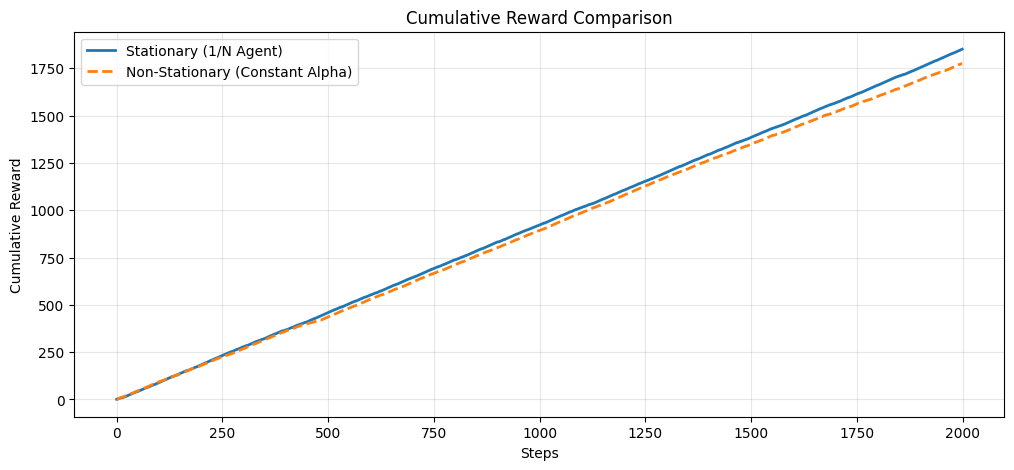

In [15]:
if __name__ == "__main__":
    NAME = "MOSTAFA"
    STEPS = 2000
    
    # --- Round 1: Stationary Casino (1/N Agent) ---
    print("--- ROUND 1: Stationary Environment ---")
    env_stat = CasinoEnvironment(is_non_stationary=False, seed=42)
    agent_stat = SampleAverageAgent(n_arms=10, epsilon=0.1, seed=123)
    
    rewards_r1 = run_simulation(env_stat, agent_stat, STEPS)
    save_submission("outputs/Exercise#1_submissions_round1.csv", NAME, "SampleAverage", "eps=0.1", STEPS, np.sum(rewards_r1))

    # --- Round 2: Non-Stationary Casino (Constant Alpha Agent) ---
    print("\n--- ROUND 2: Non-Stationary Environment ---")
    env_non_stat = CasinoEnvironment(is_non_stationary=True, drift_scale=0.01, seed=2025)
    agent_non_stat = ConstantAlphaAgent(n_arms=10, epsilon=0.1, alpha=0.1, seed=123)
    
    rewards_r2 = run_simulation(env_non_stat, agent_non_stat, STEPS)
    save_submission("outputs/Exercise#1_submissions_round2.csv", NAME, "ConstantAlpha", "eps=0.1, alpha=0.1", STEPS, np.sum(rewards_r2))

    # --- Visualizing the Difference ---
    plt.figure(figsize=(12, 5))
    plt.plot(np.cumsum(rewards_r1), label="Stationary (1/N Agent)", linewidth=2)
    plt.plot(np.cumsum(rewards_r2), label="Non-Stationary (Constant Alpha)", linewidth=2, linestyle="--")
    plt.title("Cumulative Reward Comparison")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#### Understanding the Exploration-Exploitation Trade-off ($\epsilon$ matters):

* If $\epsilon$ is strictly 0.0 (pure greed), the agent instantly locks onto the first machine that gives a reward and exploits it forever, ignoring potentially vastly superior machines. 
* If $\epsilon$ is too high (e.g., 0.9), the agent wastes time exploring terrible machines long after it should have figured out which one is the most profitable. 
* The optimal $\epsilon$ (usually around 0.1 or a decaying value) successfully handles this trade-off: it explores enough to confidently locate the best true mean, but spends the vast majority of its time actually exploiting that discovery to maximize cumulative rewards.

#### Why Constant-$\alpha$ helps in Non-Stationary Settings:

In a standard setting, the step size 1/N makes perfect sense—as the agent pulls an arm more frequently, the estimated value becomes more certain, so the step size approaches zero to lock in the true mean. However, in a non-stationary setting (Round 2), the slot machines drift over time. If the agent uses 1/N, the step size eventually becomes so small that the agent effectively stops learning, blinding it to the fact that the machines have changed. A constant-$\alpha$ acts as an Exponential Moving Average. By permanently setting the step size to 0.1, the agent ensures that recent rewards always carry a fixed, heavy weight. This allows the agent to continuously overwrite old beliefs and adapt instantly when the optimal slot machine changes.

#### How these are applied in Assignment 3 - Pong DQN

The Pong game script absolutely implements these theories natively:

1. The $\epsilon$-Greedy Trade-Off: In the DQNAgent.act() class method, the script uses the exact same if random.random() < self.epsilon logic as the bandit problem. Furthermore, we implemented self.epsilon_decay = 0.995, which gradually shifts the agent from 100% exploration at the start of the game, down to pure exploitation (playing to win) once it has learned the physics of the ball.

2. The Constant-$\alpha$ Non-Stationary Fix: In Deep Q-Learning, the "target values" calculated by the Bellman Equation are actively moving targets because the neural network updates them every batch. The environment is inherently non-stationary. This is why neural network optimizers never use a 1/N step size. Instead, we used PyTorch's optim.Adam(lr=0.0001). That learning rate (0.0001) acts as the exact equivalent of constant-$\alpha$, allowing the Pong agent to track shifting Q-values continuously without "locking up" and failing to adapt.